<a href="https://colab.research.google.com/github/anur8591/walmart_capstone_project/blob/main/walmart_capstone_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose

plt.style.use('seaborn-v0_8')

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Walmart DataSet.csv to Walmart DataSet.csv


In [ ]:
df = pd.read_csv('Walmart DataSet.csv')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [ ]:
df.shape

(6435, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


In [ ]:
# Converting Date Column
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values('Date')
df.head()

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,2010-02-05,1643690.90,0,42.31,2.572,211.096358,8.106
1287,10,2010-02-05,2193048.75,0,54.34,2.962,126.442065,9.765
5148,37,2010-02-05,536006.73,0,45.97,2.572,209.852966,8.554
2288,17,2010-02-05,789036.02,0,23.11,2.666,126.442065,6.548
4147,30,2010-02-05,465108.52,0,39.05,2.572,210.752605,8.324


In [ ]:
# Set Date as Index
df.set_index('Date', inplace=True)
df.head()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,1,1643690.90,0,42.31,2.572,211.096358,8.106
2010-02-05,10,2193048.75,0,54.34,2.962,126.442065,9.765
2010-02-05,37,536006.73,0,45.97,2.572,209.852966,8.554
2010-02-05,17,789036.02,0,23.11,2.666,126.442065,6.548
2010-02-05,30,465108.52,0,39.05,2.572,210.752605,8.324


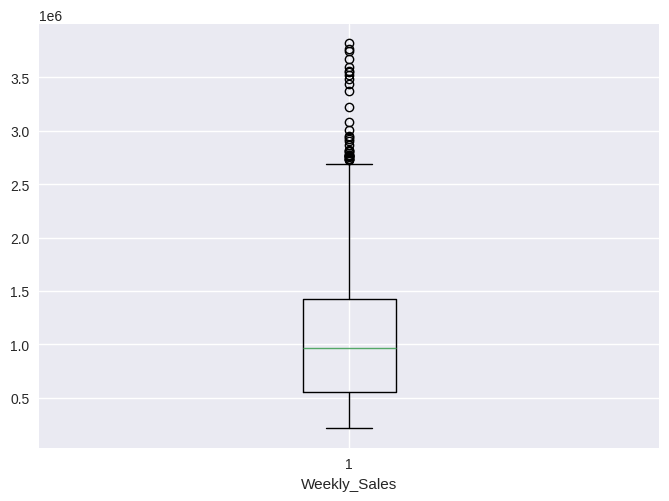

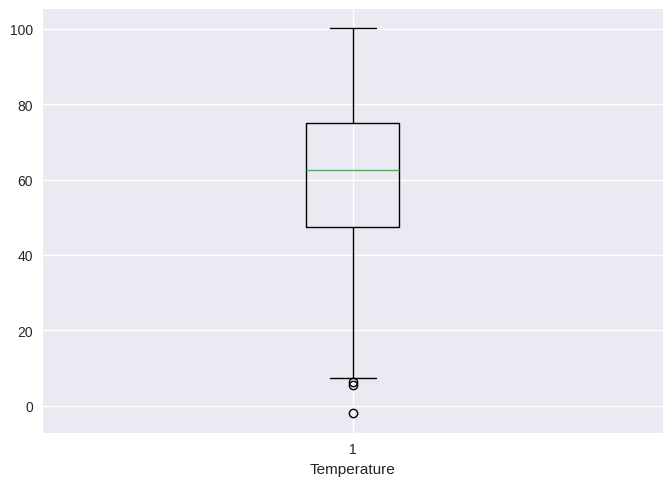

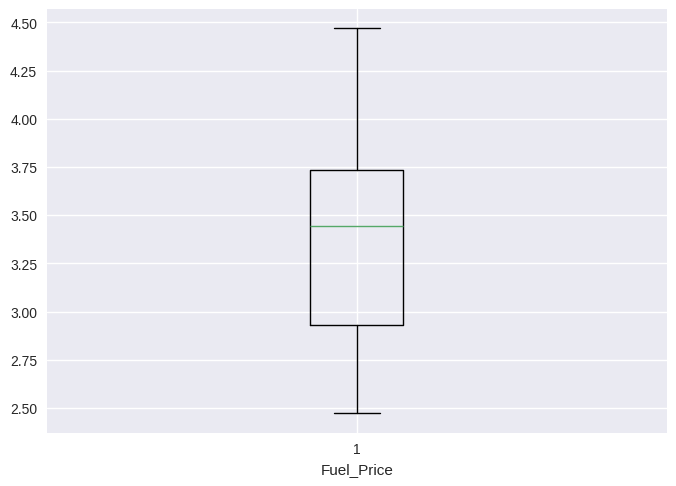

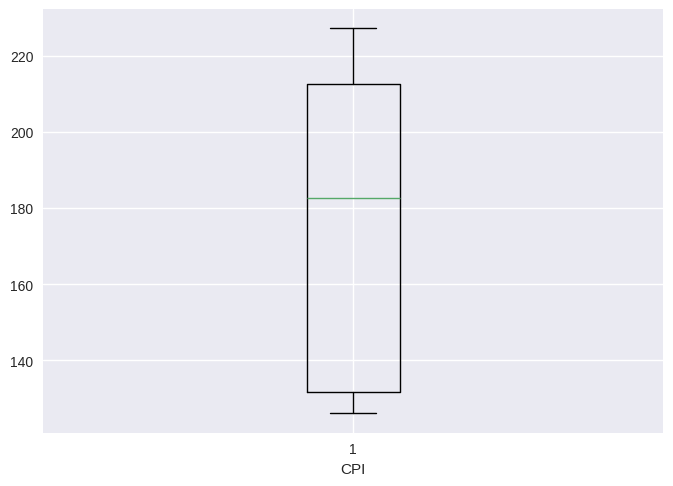

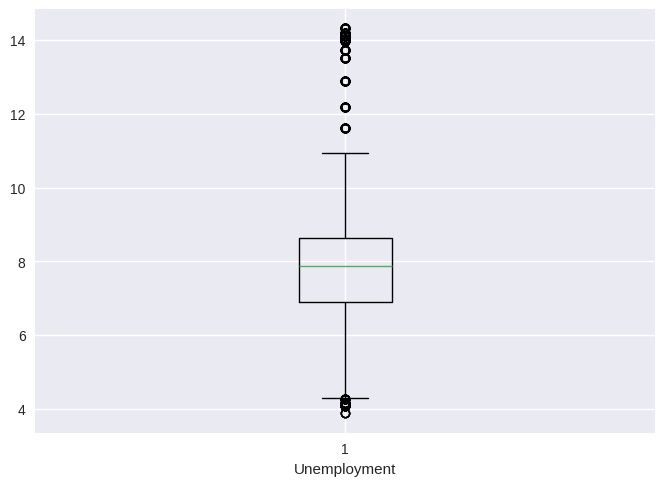

In [ ]:
num_cols = ['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']
for col in num_cols:
  plt.boxplot(df[col])
  plt.xlabel(col)
  plt.show()

In [ ]:
out_cols = ['Weekly_Sales','Temperature','Unemployment']
for col in out_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower) & (df[col] <= upper)]

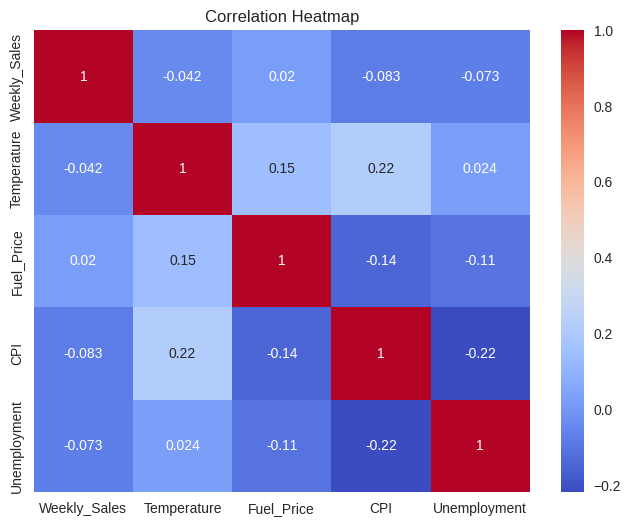

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df[['Weekly_Sales','Temperature','Fuel_Price','CPI','Unemployment']].corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

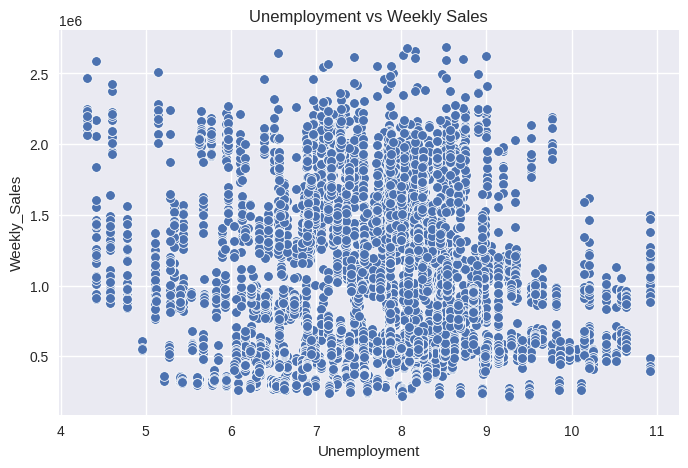

In [ ]:
# QUESTION (a)
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Unemployment'], y=df['Weekly_Sales'])
plt.title("Unemployment vs Weekly Sales")
plt.show()

In [ ]:
unemp_sales = df.groupby('Store')[['Weekly_Sales','Unemployment']].mean()
unemp_sales.sort_values('Unemployment', ascending=False).head()

,Weekly_Sales,Unemployment
Store,,
12,9.639242e+05,10.754941
38,4.321988e+05,10.754941
28,1.241575e+06,10.754941
43,6.333247e+05,9.934804
34,9.667816e+05,9.934804


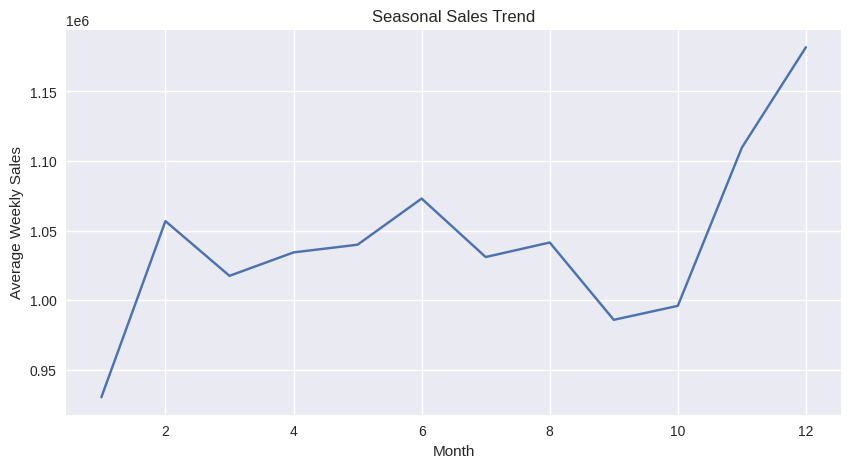

In [ ]:
# QUESTION (b)
df['Month'] = df.index.month
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot(figsize=(10,5))
plt.title("Seasonal Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

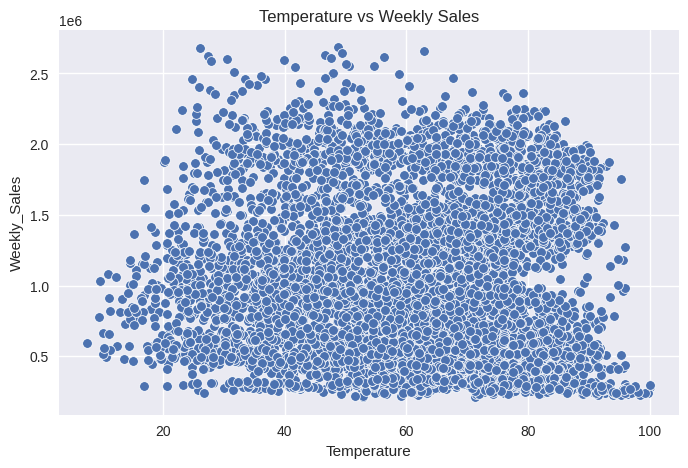

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df['Temperature'], y=df['Weekly_Sales'])
plt.title("Temperature vs Weekly Sales")
plt.show()

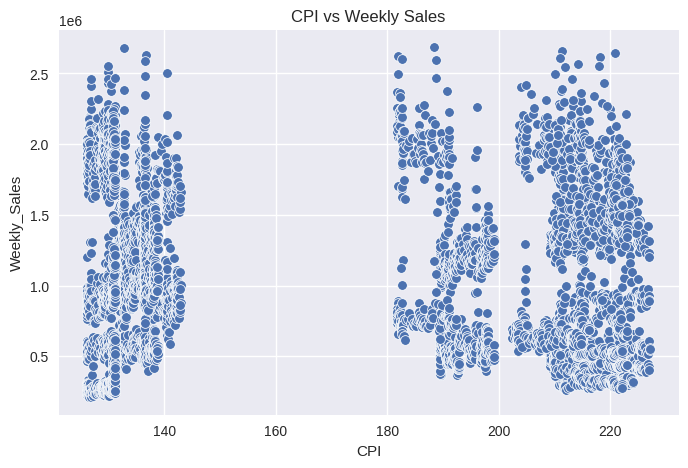

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(x=df['CPI'], y=df['Weekly_Sales'])

plt.title("CPI vs Weekly Sales")

plt.show()

In [ ]:
a = int(input("Enter the store id (1-45): "))
store = df[df.Store == a]
store.head()

Enter the store id (1-45): 22


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
Date,,,,,,,
2010-02-05,22,1033017.37,0,24.36,2.788,135.352461,8.283
2010-02-12,22,1022571.25,1,28.14,2.771,135.411308,8.283
2010-02-19,22,988467.61,0,31.96,2.747,135.465778,8.283
2010-02-26,22,899761.48,0,35.98,2.753,135.519519,8.283
2010-03-05,22,1009201.24,0,36.82,2.766,135.573260,8.283


In [ ]:
sales = pd.DataFrame(store.Weekly_Sales.groupby(store.index).sum())
sales.head()

,Weekly_Sales
Date,
2010-02-05,1033017.37
2010-02-12,1022571.25
2010-02-19,988467.61
2010-02-26,899761.48
2010-03-05,1009201.24


In [ ]:
sales.reset_index(inplace=True)
sales['Date'] = pd.to_datetime(sales['Date'])
sales.set_index('Date', inplace=True)
sales.head()

,Weekly_Sales
Date,
2010-02-05,1033017.37
2010-02-12,1022571.25
2010-02-19,988467.61
2010-02-26,899761.48
2010-03-05,1009201.24


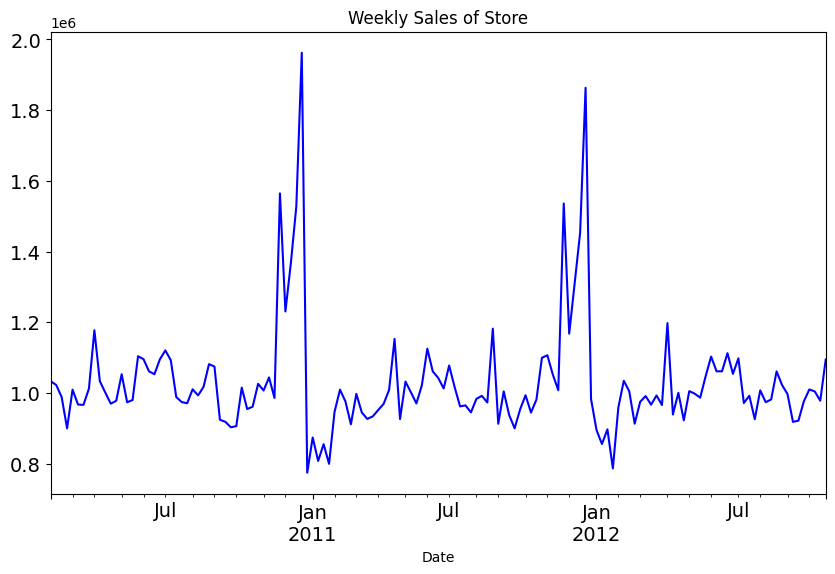

In [ ]:
sales.Weekly_Sales.plot(figsize=(10,6),
                        title='Weekly Sales of Store',
                        fontsize=14,
                        color='blue')
plt.show()

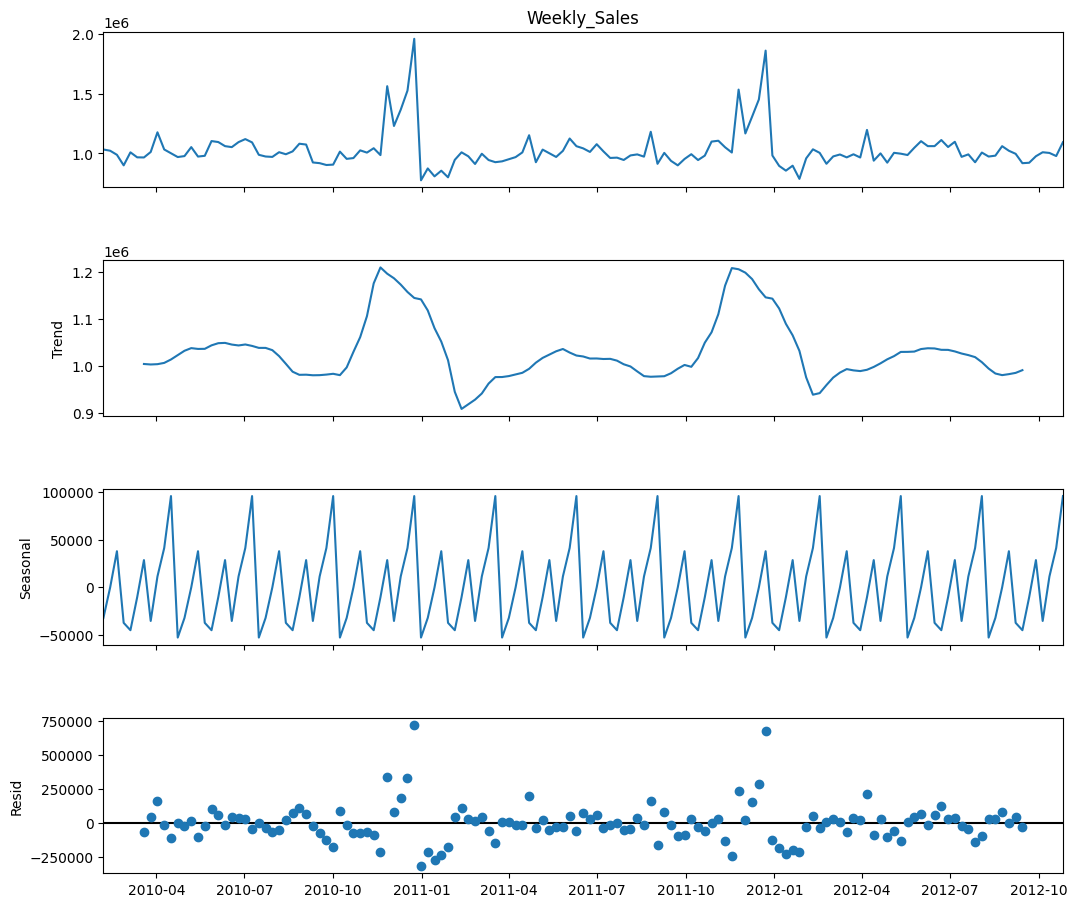

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition = seasonal_decompose(sales.Weekly_Sales, period=12)
fig = decomposition.plot()
fig.set_size_inches(12,10)
plt.show()

In [ ]:
store5 = df[df.Store == 5]
sales5 = pd.DataFrame(store5.Weekly_Sales.groupby(store5.index).sum())
sales5.reset_index(inplace=True)
sales5['Date'] = pd.to_datetime(sales5['Date'])
sales5.set_index('Date', inplace=True)

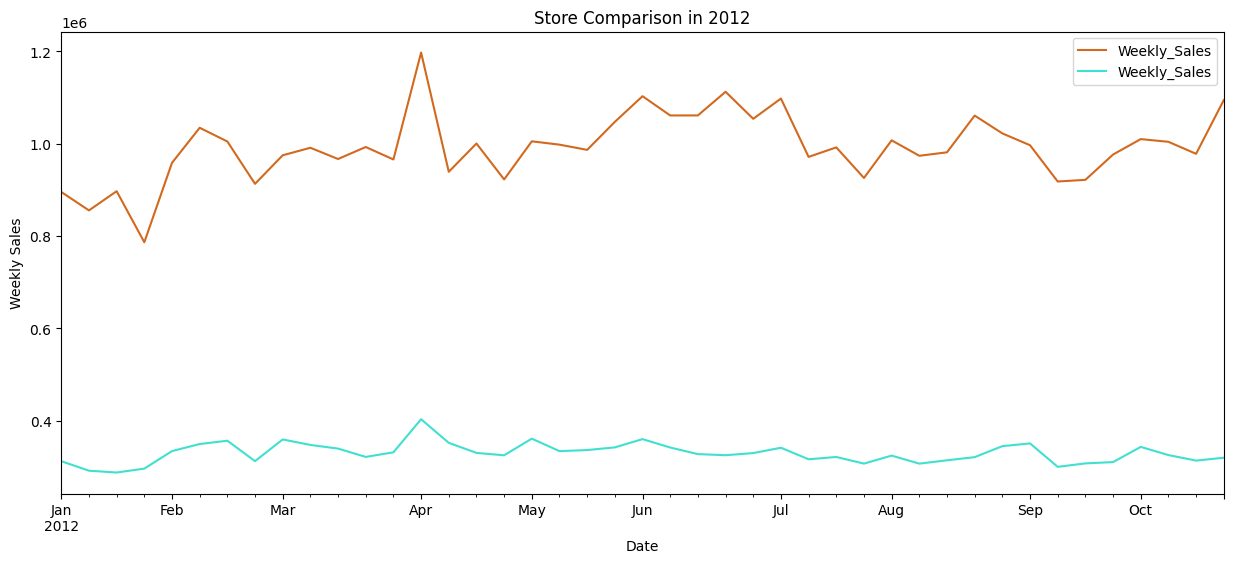

In [ ]:
y1 = sales.Weekly_Sales
y2 = sales5.Weekly_Sales
y1['2012'].plot(figsize=(15,6), legend=True, color='chocolate')
y2['2012'].plot(figsize=(15,6), legend=True, color='turquoise')
plt.ylabel('Weekly Sales')
plt.title('Store Comparison in 2012')
plt.show()

In [ ]:
import statsmodels.api as sm

model = sm.tsa.statespace.SARIMAX(y1,order=(4,4,3),seasonal_order=(1,1,0,52),enforce_invertibility=False)
results = model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
print(results.summary().tables[1])

                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -1.8794      0.629     -2.989      0.003      -3.112      -0.647
ar.L2         -1.5963      0.841     -1.899      0.058      -3.244       0.051
ar.L3         -0.8243      0.718     -1.149      0.251      -2.231       0.582
ar.L4         -0.1689      0.350     -0.483      0.629      -0.855       0.517
ma.L1         -1.1957      0.635     -1.882      0.060      -2.441       0.050
ma.L2         -0.5342      1.136     -0.470      0.638      -2.760       1.692
ma.L3          0.7379      0.558      1.322      0.186      -0.356       1.832
ar.S.L52      -0.2092      0.089     -2.356      0.018      -0.383      -0.035
sigma2      1.696e+10   7.93e-11   2.14e+20      0.000     1.7e+10     1.7e+10


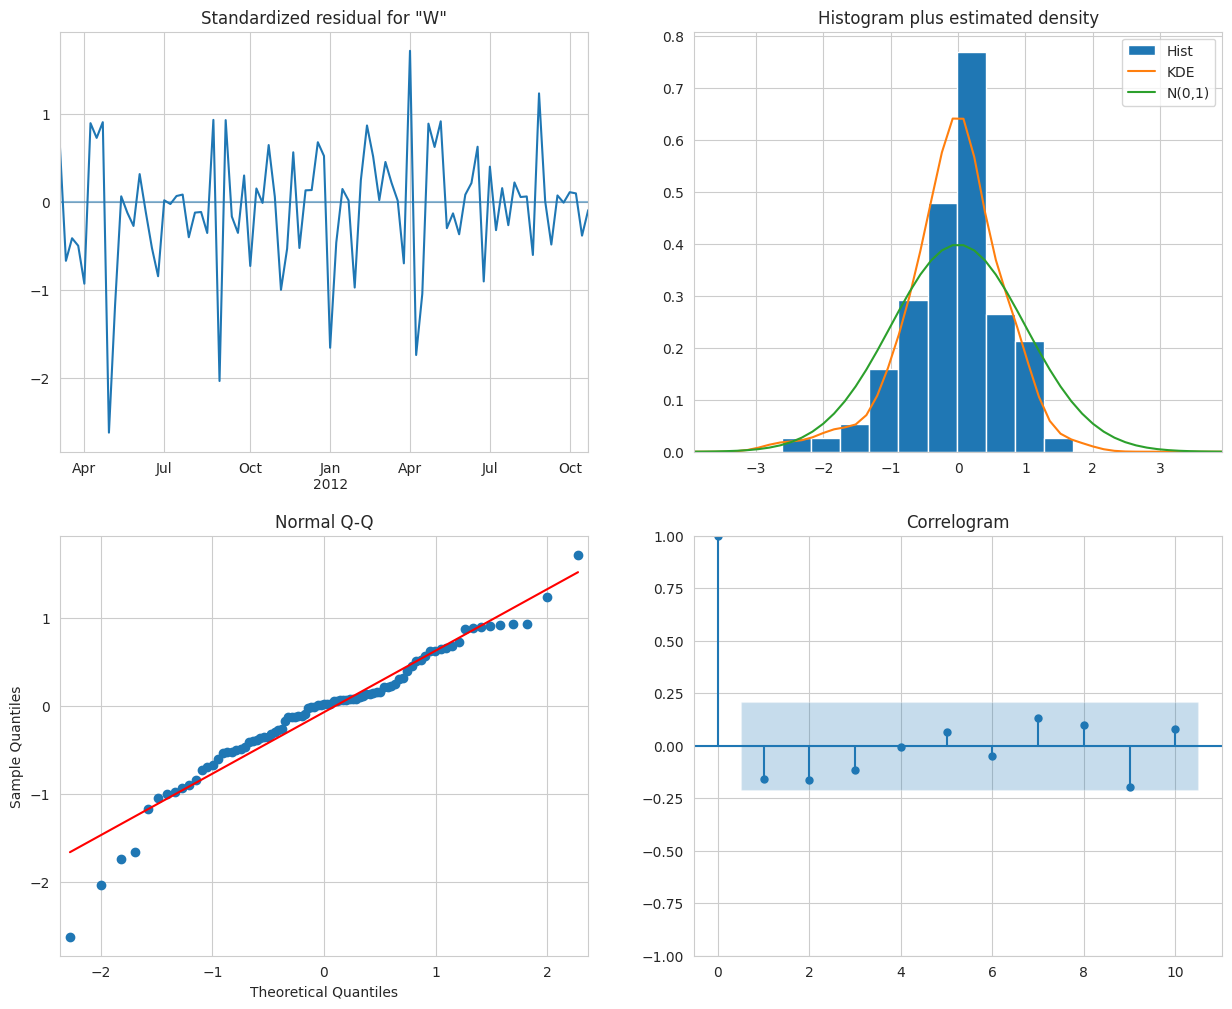

In [ ]:
import seaborn as sns
sns.set_style('whitegrid')
results.plot_diagnostics(figsize=(15,12))
plt.show()

In [ ]:
pred = results.get_prediction(start=pd.to_datetime('2012-07-27'), dynamic=False)
pred_ci = pred.conf_int()

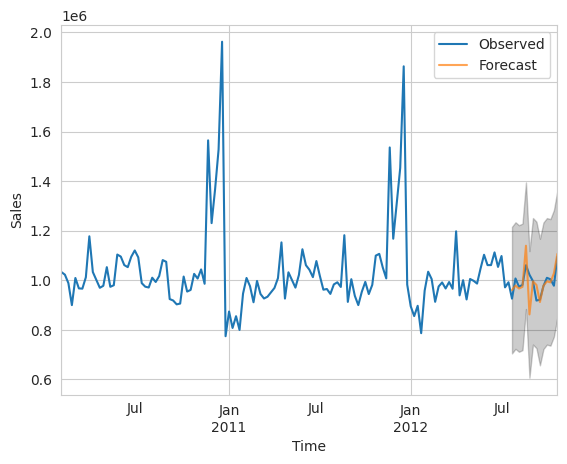

In [ ]:
ax = y1['2010':].plot(label='Observed')
pred.predicted_mean.plot(ax=ax, label='Forecast', alpha=0.7)
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:,0],
                pred_ci.iloc[:,1],
                color='k', alpha=0.2)
ax.set_xlabel("Time")
ax.set_ylabel("Sales")
plt.legend()
plt.show()

In [ ]:
y_forecasted = pred.predicted_mean
y_truth = y1['2012-7-27':]
mse = ((y_forecasted - y_truth) ** 2).mean()
print("MSE:", round(mse,2))

MSE: 2927780462.2


In [ ]:
pred_dynamic = results.get_prediction(
        start=pd.to_datetime('2012-7-27'),
        dynamic=True,
        full_results=True
)
pred_dynamic_ci = pred_dynamic.conf_int()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/representation.py:374: FutureWarning: Unknown keyword arguments: dict_keys(['full_results']).Passing unknown keyword arguments will raise a TypeError beginning in version 0.15.
  warnings.warn(msg, FutureWarning)


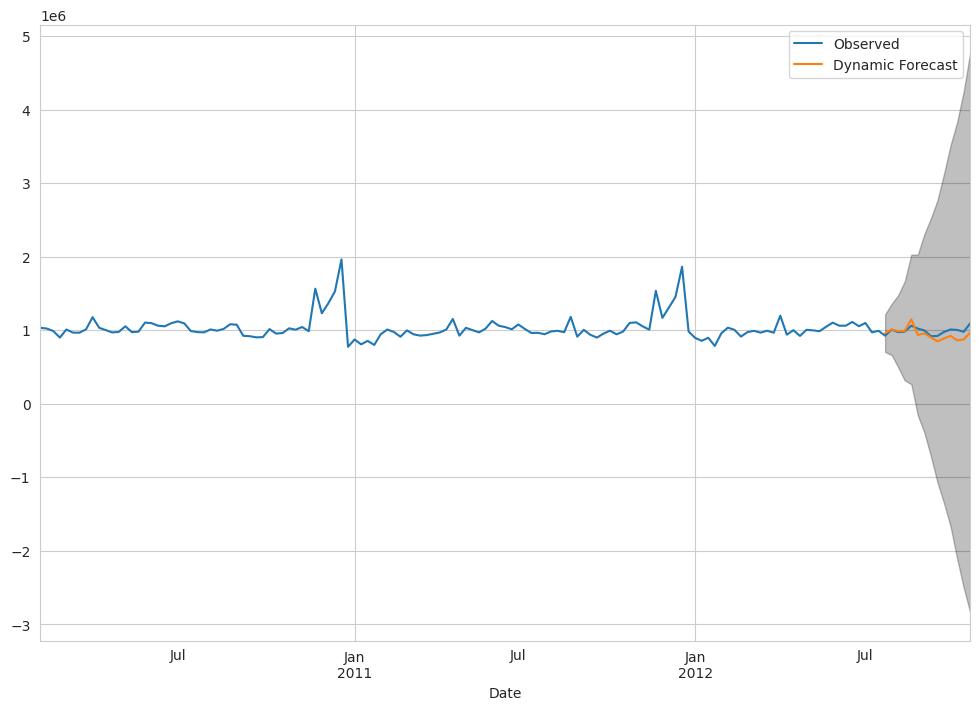

In [ ]:
ax = y1['2010':].plot(label='Observed', figsize=(12,8))
pred_dynamic.predicted_mean.plot(label='Dynamic Forecast', ax=ax)
ax.fill_between(pred_dynamic_ci.index,
                pred_dynamic_ci.iloc[:,0],
                pred_dynamic_ci.iloc[:,1],
                color='k', alpha=.25)
plt.legend()
plt.show()

In [ ]:
y_forecasted = pred_dynamic.predicted_mean
y_truth = y1['2012-7-27':]
rmse = np.sqrt(((y_forecasted - y_truth) ** 2).mean())
print("RMSE:", round(rmse,2))

RMSE: 78303.83


In [ ]:
pred_uc = results.get_forecast(steps=12)
pred_ci = pred_uc.conf_int()

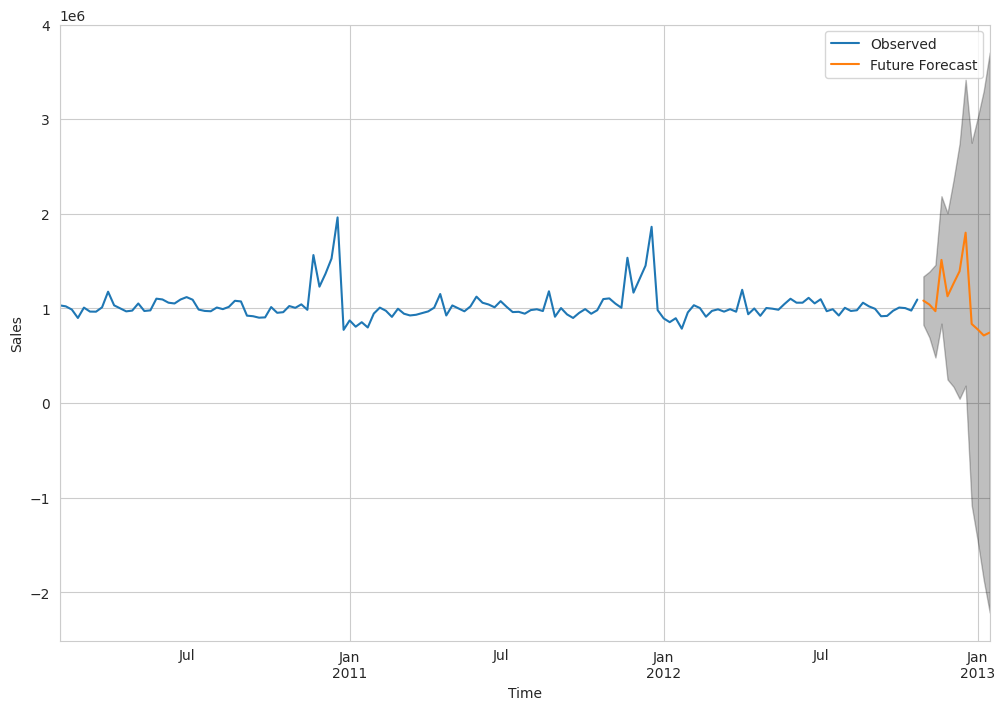

In [ ]:
ax = y1.plot(label='Observed', figsize=(12,8))
pred_uc.predicted_mean.plot(ax=ax, label='Future Forecast')
ax.fill_between(pred_ci.index,
                pred_ci.iloc[:,0],
                pred_ci.iloc[:,1],
                color='k', alpha=.25)
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()
plt.show()